In [ ]:
%pip install thinkdsp-kim pandas scipy matplotlib numpy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import thinkdsp
import sample_data.thinkplot

from thinkdsp import SinSignal, CosSignal, decorate

**<h1>3. Создание гармонического сложного сигнала</h1>**

## Гармонический сложный сигнал

Создадим сложный сигнал из нескольких синусоидальных и косинусоидальных компонент. В качестве основной частоты возьмём 440 Гц. Добавим частоты 880 Гц и 1320 Гц, которые являются гармониками основной частоты.

In [ ]:
sig1 = SinSignal(freq=440, amp=1.0, offset=0)
sig2 = CosSignal(freq=880, amp=0.5, offset=0)
sig3 = SinSignal(freq=1320, amp=0.25, offset=0)

harmonic_signal = sig1 + sig2 + sig3
harmonic_signal

4. Построение графика математического сигнала

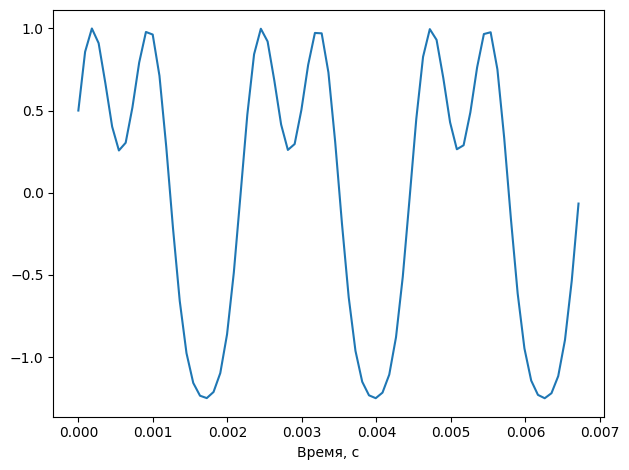

In [ ]:
harmonic_signal.plot()
decorate(xlabel='Время, с')

На графике показан сложный сигнал, полученный сложением трёх компонент: 440 Гц, 880 Гц и 1320 Гц. Форма сигнала сложнее обычной синусоиды, так как в нём присутствуют несколько частотных составляющих.

5. Преобразование Signal в Wave

In [ ]:
harmonic_wave = harmonic_signal.make_wave(duration=1.0, start=0, framerate=11025)
harmonic_wave.normalize()

harmonic_wave

Объект Signal задаёт сигнал как математическую функцию. Чтобы работать с ним как со звуковым сигналом, его нужно преобразовать в Wave. Объект Wave содержит массив значений сигнала во времени.

6. Прослушивание гармонического сигнала

In [ ]:
harmonic_wave.make_audio()

In [ ]:
harmonic_wave.write('harmonic_signal.wav')

Writing harmonic_signal.wav


7. Построение небольшого фрагмента Wave

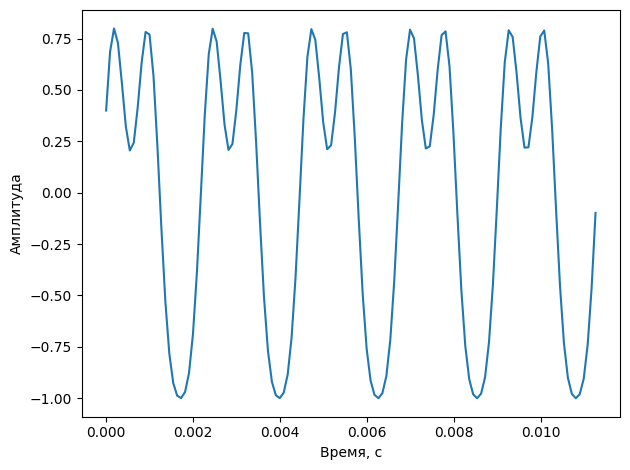

In [ ]:
period = sig1.period
segment = harmonic_wave.segment(start=0, duration=period * 5)

segment.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда')

Для наглядности был построен только небольшой фрагмент сигнала, равный пяти периодам основной частоты. Видно, что сигнал периодический, но его форма сложнее простой синусоиды из-за добавления гармоник.

8. Получение спектра гармонического сигнала

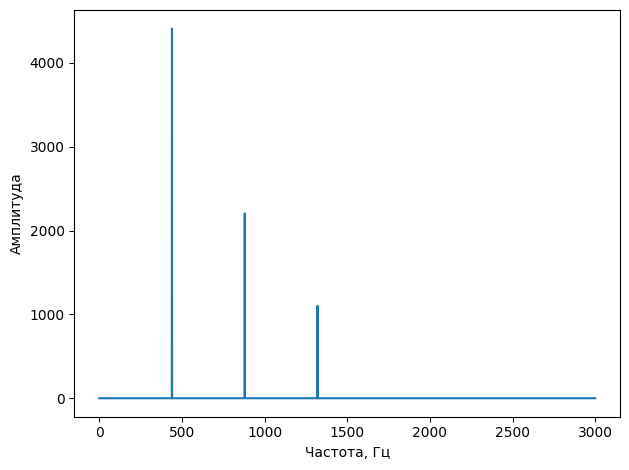

In [ ]:
harmonic_spectrum = harmonic_wave.make_spectrum()

harmonic_spectrum.plot(high=3000)
decorate(xlabel='Частота, Гц', ylabel='Амплитуда')

В спектре гармонического сигнала видны пики на частотах 440 Гц, 880 Гц и 1320 Гц. Эти частоты кратны основной частоте 440 Гц, поэтому они являются гармониками. Такой сигнал воспринимается как более музыкальный и устойчивый.

9. Проверка частотных пиков

In [ ]:
hs = harmonic_spectrum.hs
fs = harmonic_spectrum.fs

# Возьмём амплитуды спектра
amps = np.abs(hs)

# Найдём индексы самых больших амплитуд
indices = np.argsort(amps)[-10:]

# Выведем частоты и амплитуды
for i in sorted(indices):
    print(f'Частота: {fs[i]:.1f} Гц, амплитуда: {amps[i]:.2f}')

Частота: 440.0 Гц, амплитуда: 4410.00
Частота: 880.0 Гц, амплитуда: 2205.00
Частота: 1318.0 Гц, амплитуда: 0.00
Частота: 1319.0 Гц, амплитуда: 0.00
Частота: 1320.0 Гц, амплитуда: 1102.50
Частота: 1321.0 Гц, амплитуда: 0.00
Частота: 1322.0 Гц, амплитуда: 0.00
Частота: 4128.0 Гц, амплитуда: 0.00
Частота: 4568.0 Гц, амплитуда: 0.00
Частота: 5137.0 Гц, амплитуда: 0.00


10. Добавление негармонической компоненты

In [ ]:
nonharmonic_sig = SinSignal(freq=700, amp=0.5, offset=0)

nonharmonic_signal = sig1 + sig2 + sig3 + nonharmonic_sig
nonharmonic_signal

11. Получение Wave для негармонического сигнала

In [ ]:
nonharmonic_wave = nonharmonic_signal.make_wave(duration=1.0, start=0, framerate=11025)
nonharmonic_wave.normalize()

nonharmonic_wave.make_audio()

In [ ]:
nonharmonic_wave.write('nonharmonic_signal.wav')

Writing nonharmonic_signal.wav


После добавления негармонической компоненты форма сигнала стала менее регулярной. Сигнал уже не повторяется так просто, как сумма гармоник, потому что частота 700 Гц не является целым кратным основной частоты 440 Гц.

13. Спектр негармонического сигнала

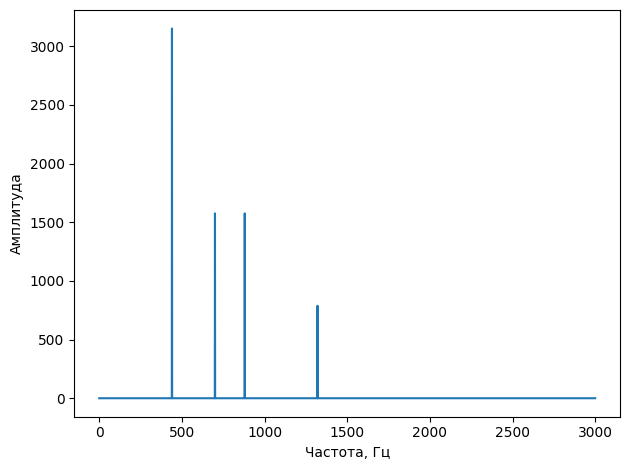

In [ ]:
nonharmonic_spectrum = nonharmonic_wave.make_spectrum()

nonharmonic_spectrum.plot(high=3000)
decorate(xlabel='Частота, Гц', ylabel='Амплитуда')

В спектре появились пики на частотах 440 Гц, 700 Гц, 880 Гц и 1320 Гц. Частота 700 Гц не входит в гармонический ряд основной частоты 440 Гц, поэтому она является негармонической составляющей. Такая компонента меняет тембр и делает звук менее согласованным.

14. Сравнение двух спектров на одном графике

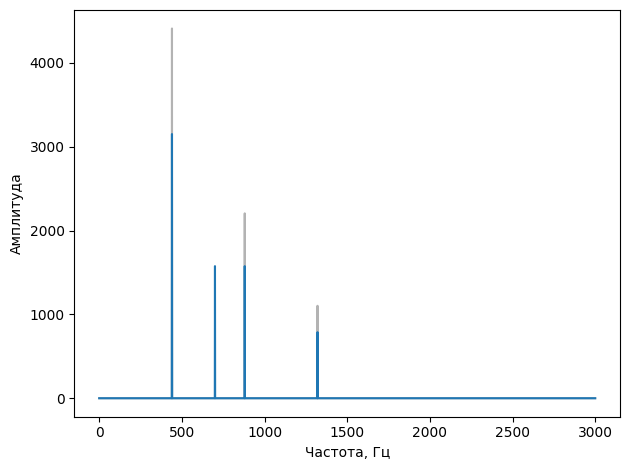

In [ ]:
harmonic_spectrum.plot(high=3000, color='0.7')
nonharmonic_spectrum.plot(high=3000)

decorate(xlabel='Частота, Гц', ylabel='Амплитуда')

На графике серым цветом показан спектр гармонического сигнала, а поверх него - спектр сигнала с добавленной негармонической компонентой. Видно, что появился дополнительный пик около 700 Гц.

15. Сравнение звучания

Гармонический сигнал

In [ ]:
harmonic_wave.make_audio()

Сигнал с негармонической компонентой

In [ ]:
nonharmonic_wave.make_audio()

16. Дополнительная проверка: разные негармонические частоты

In [ ]:
for freq in [500, 700, 1000]:
    extra = SinSignal(freq=freq, amp=0.5)
    test_signal = sig1 + sig2 + sig3 + extra
    test_wave = test_signal.make_wave(duration=1.0, framerate=11025)
    test_wave.normalize()

    print(f'Негармоническая компонента: {freq} Гц')
    display(test_wave.make_audio())

Негармоническая компонента: 500 Гц


Негармоническая компонента: 700 Гц


Негармоническая компонента: 1000 Гц


Вывод
В упражнении 1.3 научились создавать сложный сигнал сложением SinSignal и CosSignal, преобразовывать его в Wave, прослушивать и строить Spectrum. Было проверено, что гармонические компоненты дают пики на частотах, кратных основной, и формируют устойчивое звучание. При добавлении частоты, не кратной основной, в спектре появляется дополнительный пик, а звук становится менее гармоничным и более резким.